# Classification Evaluation Metrics
## A Practical Workshop for Data Professionals

---

### What we'll cover today:

| Section | Topic |
|---------|-------|
| 1 | Why evaluation metrics matter |
| 2 | Accuracy |
| 3 | Why accuracy can be misleading |
| 4 | Confusion Matrix |
| 5 | Precision |
| 6 | Recall |
| 7 | Precision vs Recall Tradeoff |
| 8 | F1 Score |
| 9 | ROC Curve & AUC |
| 10 | Putting It All Together |

---

> **Workshop philosophy:** Every concept starts with intuition. We'll always answer *"What does this mean in plain English?"* before we touch any code.


In [1]:
# Run this cell first — it loads all the libraries we'll use throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    classification_report
)

# Notebook-wide style settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
COLORS = {'tp': '#2ecc71', 'tn': '#3498db', 'fp': '#e74c3c', 'fn': '#f39c12'}

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Section 1 — Why We Need Evaluation Metrics

### Intuition

Imagine you're hiring someone and you ask them: *"How good are you at this job?"*

If they say **"I'm great!"** — that tells you nothing useful. You need a concrete way to measure performance.

The same is true for machine learning models. After training a model, we need to ask:
- **How well does it actually perform?**
- **Where does it fail?**
- **Is it good enough for our use case?**

Evaluation metrics answer these questions — but the tricky part is: **different problems need different metrics.**

---

### A simple classification example

Let's say we built a model that predicts whether an email is **spam** or **not spam**.

Here are 10 emails and what happened:

| Email | True Label | Model Prediction | Correct? |
|-------|-----------|-----------------|----------|
| 1 | Spam | Spam | ✅ |
| 2 | Not Spam | Not Spam | ✅ |
| 3 | Spam | Not Spam | ❌ |
| 4 | Not Spam | Spam | ❌ |
| 5 | Not Spam | Not Spam | ✅ |
| 6 | Spam | Spam | ✅ |
| 7 | Spam | Spam | ✅ |
| 8 | Not Spam | Not Spam | ✅ |
| 9 | Spam | Not Spam | ❌ |
| 10 | Not Spam | Not Spam | ✅ |

The model got **7 out of 10** correct. But is that good? It depends on **what matters**.

> **Key insight:** The question is not just *"how many did we get right?"* but *"what types of mistakes are we making, and how costly are they?"*

In [2]:
# Let's represent that table as data
emails = pd.DataFrame({
    'Email': range(1, 11),
    'True Label': ['Spam','Not Spam','Spam','Not Spam','Not Spam','Spam','Spam','Not Spam','Spam','Not Spam'],
    'Prediction': ['Spam','Not Spam','Not Spam','Spam','Not Spam','Spam','Spam','Not Spam','Not Spam','Not Spam']
})

emails['Correct'] = emails['True Label'] == emails['Prediction']
print(emails.to_string(index=False))
print(f"\nCorrect predictions: {emails['Correct'].sum()} / {len(emails)}")

 Email True Label Prediction  Correct
     1       Spam       Spam     True
     2   Not Spam   Not Spam     True
     3       Spam   Not Spam    False
     4   Not Spam       Spam    False
     5   Not Spam   Not Spam     True
     6       Spam       Spam     True
     7       Spam       Spam     True
     8   Not Spam   Not Spam     True
     9       Spam   Not Spam    False
    10   Not Spam   Not Spam     True

Correct predictions: 7 / 10


---
## Section 2 — Accuracy

### Intuition

Accuracy is the most natural metric. It simply asks:

> **Out of all predictions, how many did we get right?**

$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}$$

It's like a test score: if you answered 90 out of 100 questions correctly, your accuracy is 90%.

---

### Simple Example

In [3]:
# Simple example — matching the intuition table
predictions = ['Yes', 'No', 'Yes', 'Yes', 'No']
labels      = ['Yes', 'Yes', 'Yes', 'No',  'No']

# Manual calculation
correct = sum(p == l for p, l in zip(predictions, labels))
total = len(labels)
manual_accuracy = correct / total

print("Predictions:", predictions)
print("True Labels:", labels)
print()
print(f"Correct predictions: {correct} out of {total}")
print(f"Manual accuracy: {correct}/{total} = {manual_accuracy:.2%}")

Predictions: ['Yes', 'No', 'Yes', 'Yes', 'No']
True Labels: ['Yes', 'Yes', 'Yes', 'No', 'No']

Correct predictions: 3 out of 5
Manual accuracy: 3/5 = 60.00%


In [4]:
# sklearn gives the same result with one line
# We need numbers for sklearn: 1 = Yes, 0 = No
preds_num  = [1, 0, 1, 1, 0]
labels_num = [1, 1, 1, 0, 0]

acc = accuracy_score(labels_num, preds_num)
print(f"sklearn accuracy_score: {acc:.2%}")

sklearn accuracy_score: 60.00%


### Visualization — What do our predictions look like?

/var/folders/8l/vy79x4r97dn8s56m1p40s5lw0000gn/T/ipykernel_40227/2409636272.py:22: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/8l/vy79x4r97dn8s56m1p40s5lw0000gn/T/ipykernel_40227/2409636272.py:22: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/Users/abdellatif/Desktop/Project-space/ironhack/session/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/abdellatif/Desktop/Project-space/ironhack/session/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


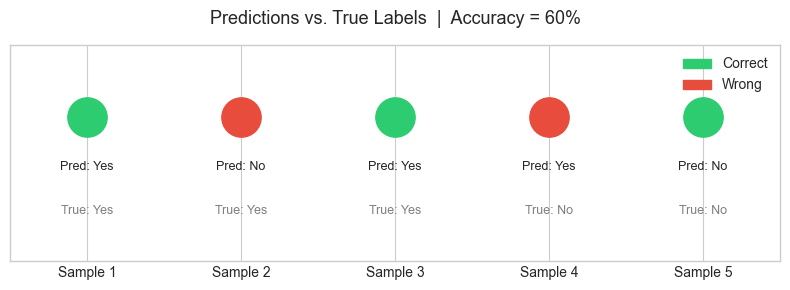

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))

for i, (pred, label) in enumerate(zip(preds_num, labels_num)):
    color = '#2ecc71' if pred == label else '#e74c3c'
    symbol = '✓' if pred == label else '✗'
    ax.scatter(i, 0.5, s=800, color=color, zorder=5)
    ax.text(i, 0.5, symbol, ha='center', va='center', fontsize=16, color='white', fontweight='bold')
    ax.text(i, 0.15, f'Pred: {"Yes" if pred else "No"}', ha='center', va='center', fontsize=9)
    ax.text(i, -0.15, f'True: {"Yes" if label else "No"}', ha='center', va='center', fontsize=9, color='gray')

ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.5, 1)
ax.set_yticks([])
ax.set_xticks(range(5))
ax.set_xticklabels([f'Sample {i+1}' for i in range(5)])
ax.set_title(f'Predictions vs. True Labels  |  Accuracy = {acc:.0%}', fontsize=13, pad=15)

correct_patch = mpatches.Patch(color='#2ecc71', label='Correct')
wrong_patch   = mpatches.Patch(color='#e74c3c', label='Wrong')
ax.legend(handles=[correct_patch, wrong_patch], loc='upper right')

plt.tight_layout()
plt.show()

---
## Section 3 — Why Accuracy Can Be Misleading

### Intuition

Here's a riddle:

> A model predicts that **every single patient is healthy**. It achieves **99% accuracy**. Is it a good model?

Intuitively — **No!** A model that never detects disease is completely useless, even if it's "99% accurate."

This is the **imbalanced dataset problem**.

---

### The Sick Patient Example

In [7]:
# Dataset: 1000 patients, 990 healthy, 10 sick
n_healthy = 990
n_sick = 10
n_total = n_healthy + n_sick

# True labels: 0 = healthy, 1 = sick
true_labels = [0] * n_healthy + [1] * n_sick

# A lazy model that always predicts 'healthy'
lazy_predictions = [0] * n_total

lazy_accuracy = accuracy_score(true_labels, lazy_predictions)

print(f"Dataset: {n_healthy} healthy, {n_sick} sick ({n_total} total)")
print(f"Lazy model: always predicts 'healthy'")
print(f"Accuracy: {lazy_accuracy:.2%}")
print()
print("The model missed ALL 10 sick patients — but still scored 99% accuracy!")
print("This is why accuracy alone can be dangerously misleading.")

Dataset: 990 healthy, 10 sick (1000 total)
Lazy model: always predicts 'healthy'
Accuracy: 99.00%

The model missed ALL 10 sick patients — but still scored 99% accuracy!
This is why accuracy alone can be dangerously misleading.


### Visualization — Class Imbalance

/var/folders/8l/vy79x4r97dn8s56m1p40s5lw0000gn/T/ipykernel_40227/1739027734.py:30: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) Arial.
  plt.tight_layout()
/Users/abdellatif/Desktop/Project-space/ironhack/session/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127881 (\N{PARTY POPPER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


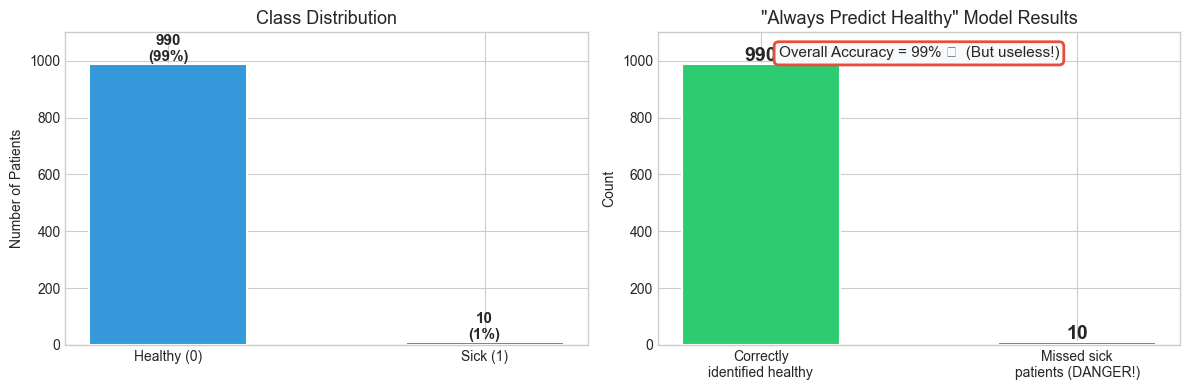

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: class distribution
ax1 = axes[0]
bars = ax1.bar(['Healthy (0)', 'Sick (1)'], [n_healthy, n_sick],
               color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=1.5, width=0.5)
ax1.set_title('Class Distribution', fontsize=13)
ax1.set_ylabel('Number of Patients')
for bar, val in zip(bars, [n_healthy, n_sick]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val}\n({val/n_total:.0%})', ha='center', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1100)

# Right: what happens when we always predict healthy
ax2 = axes[1]
categories = ['Correctly\nidentified healthy', 'Missed sick\npatients (DANGER!)']
values = [n_healthy, n_sick]
colors = ['#2ecc71', '#e74c3c']
bars2 = ax2.bar(categories, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
ax2.set_title('"Always Predict Healthy" Model Results', fontsize=13)
ax2.set_ylabel('Count')
for bar, val in zip(bars2, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 1100)
ax2.text(0.5, 0.92, f'Overall Accuracy = {lazy_accuracy:.0%} 🎉  (But useless!)',
         ha='center', transform=ax2.transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#e74c3c', linewidth=2))

plt.tight_layout()
plt.show()

---
## Section 4 — Confusion Matrix

### Intuition

A confusion matrix is a table that shows **exactly what types of mistakes** our model is making.

Instead of one number (accuracy), we get **four numbers** — one for each combination of *what the model predicted* and *what was actually true*.

| | **Predicted: Negative** | **Predicted: Positive** |
|---|---|---|
| **Actual: Negative** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual: Positive** | False Negative (FN) ❌ | True Positive (TP) ✅ |

**The four boxes explained:**

- **True Positive (TP):** Model said *"Sick"*, patient is actually *sick*. Correct!
- **True Negative (TN):** Model said *"Healthy"*, patient is actually *healthy*. Correct!
- **False Positive (FP):** Model said *"Sick"*, but patient is actually *healthy*. **False alarm.**
- **False Negative (FN):** Model said *"Healthy"*, but patient is actually *sick*. **Missed case!** (Often the most dangerous)

---

### A Memory Trick

Think of a **pregnancy test**:
- **True Positive:** Test says pregnant → you ARE pregnant ✅
- **True Negative:** Test says not pregnant → you are NOT pregnant ✅
- **False Positive:** Test says pregnant → you are NOT pregnant (false alarm) ⚠️
- **False Negative:** Test says not pregnant → you ARE pregnant (missed!) ❌

In [9]:
# Small disease detection example
# 1 = Sick, 0 = Healthy
y_true = [1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
          0, 1, 0, 0, 1, 1, 0, 1, 0, 0]

y_pred = [1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
          0, 1, 0, 0, 1, 0, 0, 1, 1, 0]

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)
print()

TN, FP, FN, TP = cm.ravel()
print(f"True Negatives  (TN): {TN}  — Correctly predicted HEALTHY")
print(f"False Positives (FP): {FP}  — Predicted sick but actually HEALTHY (false alarm)")
print(f"False Negatives (FN): {FN}  — Predicted healthy but actually SICK (missed case!)")
print(f"True Positives  (TP): {TP}  — Correctly predicted SICK")

Confusion Matrix:
[[9 2]
 [3 6]]

True Negatives  (TN): 9  — Correctly predicted HEALTHY
False Positives (FP): 2  — Predicted sick but actually HEALTHY (false alarm)
False Negatives (FN): 3  — Predicted healthy but actually SICK (missed case!)
True Positives  (TP): 6  — Correctly predicted SICK


### Visualization — Confusion Matrix Heatmap

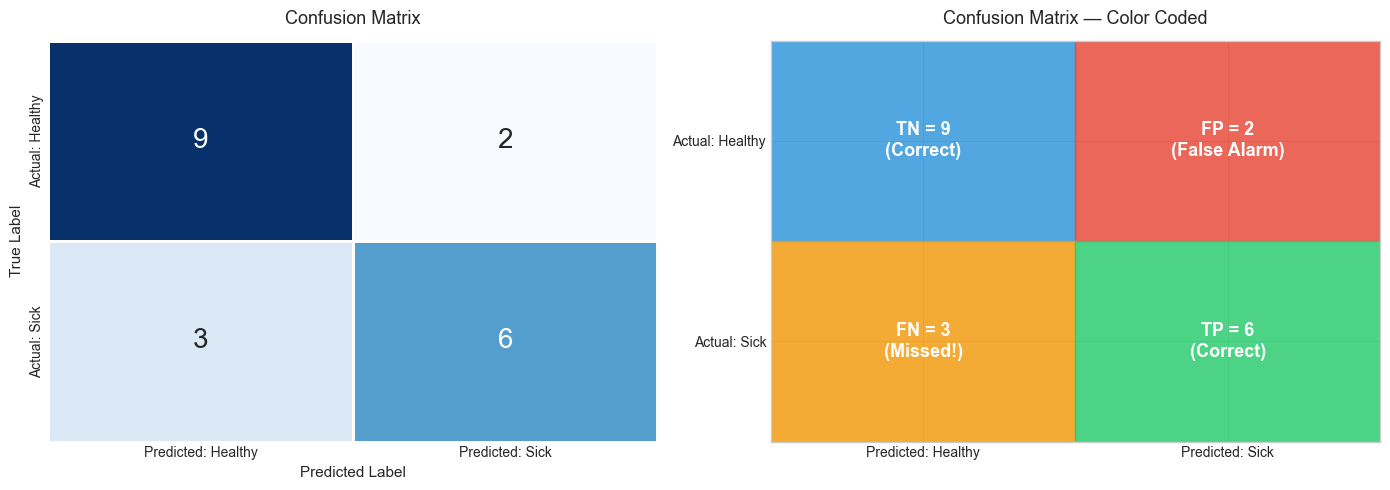

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the standard confusion matrix
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Predicted: Healthy', 'Predicted: Sick'],
            yticklabels=['Actual: Healthy', 'Actual: Sick'],
            linewidths=2, linecolor='white', cbar=False, annot_kws={'size': 20})
ax1.set_title('Confusion Matrix', fontsize=13, pad=12)
ax1.set_xlabel('Predicted Label', fontsize=11)
ax1.set_ylabel('True Label', fontsize=11)

# Right: color-coded explanation
ax2 = axes[1]
labels_matrix = np.array([[f'TN = {TN}\n(Correct)', f'FP = {FP}\n(False Alarm)'],
                           [f'FN = {FN}\n(Missed!)', f'TP = {TP}\n(Correct)']])
colors_matrix = np.array([[COLORS['tn'], COLORS['fp']],
                           [COLORS['fn'], COLORS['tp']]])

for i in range(2):
    for j in range(2):
        ax2.add_patch(plt.Rectangle([j, 1-i], 1, 1, color=colors_matrix[i, j], alpha=0.85))
        ax2.text(j + 0.5, 1 - i + 0.5, labels_matrix[i, j],
                 ha='center', va='center', fontsize=13, fontweight='bold', color='white')

ax2.set_xlim(0, 2)
ax2.set_ylim(0, 2)
ax2.set_xticks([0.5, 1.5])
ax2.set_xticklabels(['Predicted: Healthy', 'Predicted: Sick'], fontsize=10)
ax2.set_yticks([0.5, 1.5])
ax2.set_yticklabels(['Actual: Sick', 'Actual: Healthy'], fontsize=10)
ax2.set_title('Confusion Matrix — Color Coded', fontsize=13, pad=12)

plt.tight_layout()
plt.show()

---
## Section 5 — Precision

### Intuition

> **Precision answers:** *"When the model says POSITIVE, how often is it right?"*

Think of a **search engine**. When you search for something, the results it shows you are its "positive" predictions. If most results are relevant → high precision. If most results are junk → low precision.

Or think of a **fire alarm**: if it goes off 10 times and 9 of those are real fires → high precision. If it goes off 10 times and 9 are false alarms → low precision.

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} = \frac{TP}{TP + FP}$$

**In plain English:** Out of everyone we labeled as "sick", how many were actually sick?

---

### When does precision matter most?

**Spam detection:** If we label a legitimate email as spam, the user misses an important email. False positives are costly → we want **high precision**.

In [12]:
# Using our earlier confusion matrix values
print(f"Recall the values: TP={TP}, FP={FP}, FN={FN}, TN={TN}")
print()

# Manual calculation
precision_manual = TP / (TP + FP)
print(f"Precision (manual) = TP / (TP + FP) = {TP} / ({TP} + {FP}) = {precision_manual:.3f}")

# sklearn
precision_sklearn = precision_score(y_true, y_pred)
print(f"Precision (sklearn) = {precision_sklearn:.3f}")
print()
print(f"Interpretation: When the model predicted 'sick', it was correct {precision_sklearn:.0%} of the time.")

Recall the values: TP=6, FP=2, FN=3, TN=9

Precision (manual) = TP / (TP + FP) = 6 / (6 + 2) = 0.750
Precision (sklearn) = 0.750

Interpretation: When the model predicted 'sick', it was correct 75% of the time.


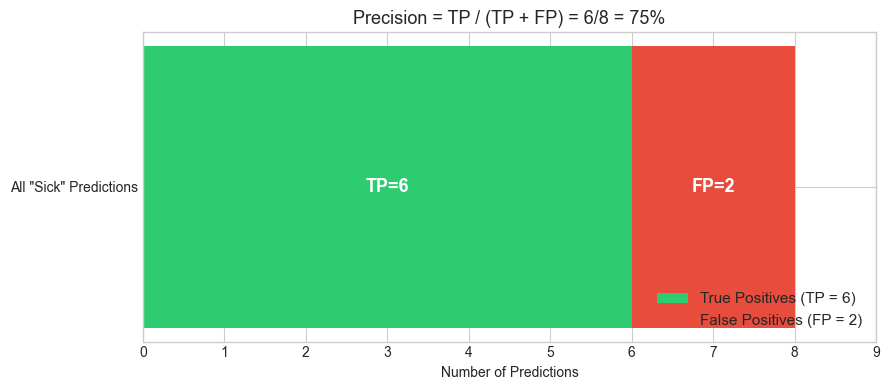


Out of 8 patients the model flagged as 'sick', only 6 were actually sick.


In [13]:
# Visual: Precision — what happens to our 'Positive' predictions
fig, ax = plt.subplots(figsize=(9, 4))

# All positive predictions = TP + FP
total_positive_preds = TP + FP

ax.barh(['All "Sick" Predictions'], [TP], color=COLORS['tp'], label=f'True Positives (TP = {TP})', height=0.5)
ax.barh(['All "Sick" Predictions'], [FP], left=[TP], color=COLORS['fp'],
        label=f'False Positives (FP = {FP})', height=0.5)

ax.set_xlim(0, total_positive_preds + 1)
ax.set_title(f'Precision = TP / (TP + FP) = {TP}/{total_positive_preds} = {precision_manual:.0%}', fontsize=13)
ax.set_xlabel('Number of Predictions')
ax.legend(loc='lower right', fontsize=11)

ax.text(TP/2, 0, f'TP={TP}', ha='center', va='center', fontsize=13, color='white', fontweight='bold')
ax.text(TP + FP/2, 0, f'FP={FP}', ha='center', va='center', fontsize=13, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nOut of {total_positive_preds} patients the model flagged as 'sick', only {TP} were actually sick.")

---
## Section 6 — Recall

### Intuition

> **Recall answers:** *"Out of ALL actual positives, how many did we find?"*

Think of a **metal detector at an airport**. You don't want it to miss any real threats. Even if it causes some false alarms, you want it to **catch everything dangerous**.

Or think of **disease screening**: if 100 people have cancer, and your test only catches 60, your recall is 60%. The other 40 walk away untreated.

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} = \frac{TP}{TP + FN}$$

**In plain English:** Out of all the sick people, how many did we actually catch?

---

### When does recall matter most?

**Disease detection, fraud detection:** Missing a true positive is catastrophic → we want **high recall**.

In [15]:
# Recall calculation
recall_manual = TP / (TP + FN)
recall_sklearn = recall_score(y_true, y_pred)

print(f"Values: TP={TP}, FN={FN}")
print(f"Recall (manual) = TP / (TP + FN) = {TP} / ({TP} + {FN}) = {recall_manual:.3f}")
print(f"Recall (sklearn) = {recall_sklearn:.3f}")
print()
print(f"Interpretation: Out of all {TP + FN} truly sick patients, we caught {recall_sklearn:.0%} of them.")
print(f"We MISSED {FN} sick patients.")

Values: TP=6, FN=3
Recall (manual) = TP / (TP + FN) = 6 / (6 + 3) = 0.667
Recall (sklearn) = 0.667

Interpretation: Out of all 9 truly sick patients, we caught 67% of them.
We MISSED 3 sick patients.


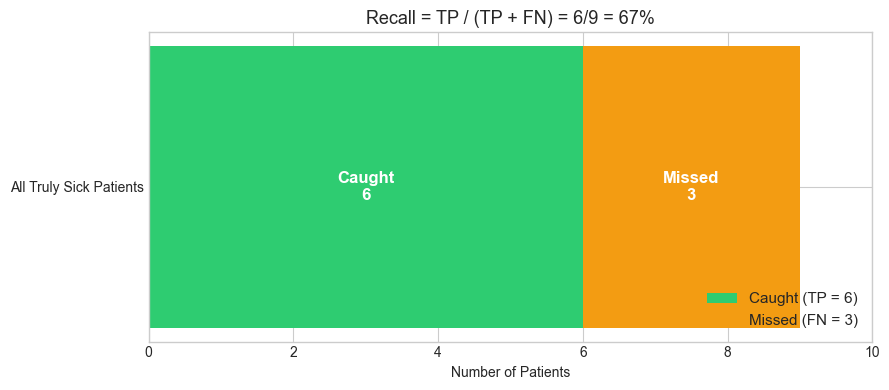

In [16]:
# Visual: Recall — what happens to all ACTUAL positives
fig, ax = plt.subplots(figsize=(9, 4))

total_actual_positive = TP + FN

ax.barh(['All Truly Sick Patients'], [TP], color=COLORS['tp'], label=f'Caught (TP = {TP})', height=0.5)
ax.barh(['All Truly Sick Patients'], [FN], left=[TP], color=COLORS['fn'],
        label=f'Missed (FN = {FN})', height=0.5)

ax.set_xlim(0, total_actual_positive + 1)
ax.set_title(f'Recall = TP / (TP + FN) = {TP}/{total_actual_positive} = {recall_manual:.0%}', fontsize=13)
ax.set_xlabel('Number of Patients')
ax.legend(loc='lower right', fontsize=11)

ax.text(TP/2, 0, f'Caught\n{TP}', ha='center', va='center', fontsize=12, color='white', fontweight='bold')
ax.text(TP + FN/2, 0, f'Missed\n{FN}', ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### Side-by-Side Comparison: Precision vs Recall

In [17]:
summary_data = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Value': [accuracy_score(y_true, y_pred), precision_manual, recall_manual],
    'Formula': ['(TP+TN)/(TP+TN+FP+FN)', 'TP/(TP+FP)', 'TP/(TP+FN)'],
    'Question Answered': [
        'Overall, how often are we right?',
        'When we say positive, are we right?',
        'Of all positives, how many did we find?'
    ]
})

print(summary_data.to_string(index=False))

   Metric    Value               Formula                       Question Answered
 Accuracy 0.750000 (TP+TN)/(TP+TN+FP+FN)        Overall, how often are we right?
Precision 0.750000            TP/(TP+FP)     When we say positive, are we right?
   Recall 0.666667            TP/(TP+FN) Of all positives, how many did we find?


---
## Section 7 — Precision vs Recall Tradeoff

### Intuition

Here's the core tension:

**If you want to catch every sick person (high recall):**
→ Flag more people as sick → more false alarms → lower precision

**If you want every flag to be certain (high precision):**
→ Only flag very obvious cases → miss borderline cases → lower recall

This is controlled by the **decision threshold** — the probability cutoff above which we predict "positive".

- Default threshold: **0.5** (if model says >50% chance of sick → predict sick)
- Lower threshold → more positives → higher recall, lower precision
- Higher threshold → fewer positives → higher precision, lower recall

---

### Demonstrating the Tradeoff

In [ ]:
# Generate a realistic dataset and train logistic regression
np.random.seed(42)
X, y = make_classification(n_samples=500, n_features=10, n_informative=5,
                            weights=[0.8, 0.2], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(random_state=42, max_iter=200)
model.fit(X_train, y_train)

# Get predicted probabilities for the positive class
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Test set: {len(y_test)} samples")
print(f"Positive class: {y_test.sum()} ({y_test.mean():.0%})")
print()
print("First 10 predicted probabilities:")
print(np.round(y_proba[:10], 3))
print("At threshold 0.5, these become:", (y_proba[:10] >= 0.5).astype(int).tolist())

Test set: 150 samples
Positive class: 36 (24%)

First 10 predicted probabilities:
[0.077 0.033 0.035 0.217 0.152 0.047 0.011 0.009 0.219 0.009]
At threshold 0.5, these become: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


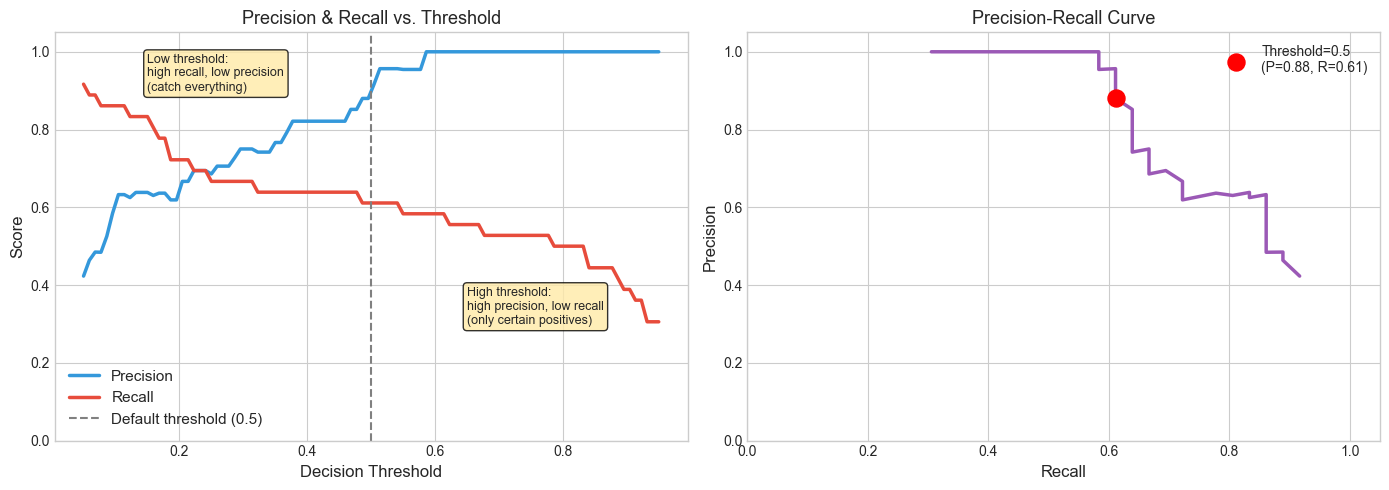

In [19]:
# Compute precision and recall at every possible threshold
thresholds = np.linspace(0.05, 0.95, 100)
precisions, recalls = [], []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    if y_pred_t.sum() == 0:  # no positive predictions
        precisions.append(1.0)
        recalls.append(0.0)
    else:
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, zero_division=0))

# Plot the tradeoff
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: both metrics vs threshold
ax1 = axes[0]
ax1.plot(thresholds, precisions, color='#3498db', lw=2.5, label='Precision')
ax1.plot(thresholds, recalls, color='#e74c3c', lw=2.5, label='Recall')
ax1.axvline(0.5, color='gray', linestyle='--', lw=1.5, label='Default threshold (0.5)')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Precision & Recall vs. Threshold', fontsize=13)
ax1.legend(fontsize=11)
ax1.set_ylim(0, 1.05)

# Add annotations
ax1.annotate('Low threshold:\nhigh recall, low precision\n(catch everything)',
             xy=(0.15, 0.9), fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#ffeaa7', alpha=0.8))
ax1.annotate('High threshold:\nhigh precision, low recall\n(only certain positives)',
             xy=(0.65, 0.3), fontsize=9,
             bbox=dict(boxstyle='round', facecolor='#ffeaa7', alpha=0.8))

# Right: precision vs recall curve
ax2 = axes[1]
ax2.plot(recalls, precisions, color='#9b59b6', lw=2.5)
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=13)
ax2.set_xlim(0, 1.05)
ax2.set_ylim(0, 1.05)

# Highlight default threshold point
y_pred_default = (y_proba >= 0.5).astype(int)
p_default = precision_score(y_test, y_pred_default)
r_default = recall_score(y_test, y_pred_default)
ax2.scatter([r_default], [p_default], s=150, color='red', zorder=5, label=f'Threshold=0.5\n(P={p_default:.2f}, R={r_default:.2f})')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Real-world examples of threshold choices:

| Use Case | Priority | Reasoning |
|----------|----------|-----------|
| Cancer screening | **High Recall** | Missing cancer is fatal; false alarms lead to more tests, not death |
| Spam filter | **High Precision** | Sending a real email to spam is more annoying than letting spam through |
| Credit card fraud (realtime) | **Balanced** | Both missing fraud and blocking legit purchases are costly |
| Airport security | **High Recall** | A missed threat is catastrophic |

---
## Section 8 — F1 Score

### Intuition

Precision and recall pull in opposite directions. Sometimes we need **one number** that summarizes both.

The **F1 score** is the harmonic mean of precision and recall:

$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Why harmonic mean and not regular average?**

The harmonic mean **punishes extreme imbalance**. If either precision or recall is very low, F1 will be low — even if the other is perfect.

Example:
- Precision = 1.0, Recall = 0.1 → Regular average = 0.55, **F1 = 0.18**
- Precision = 0.9, Recall = 0.8 → Regular average = 0.85, **F1 = 0.847**

F1 is **more honest** — it won't let one good metric hide a terrible one.

In [20]:
# Demonstrating why harmonic mean is better
scenarios = [
    ('High P, Low R (gaming recall)',   1.0, 0.1),
    ('Low P, High R (gaming precision)', 0.1, 1.0),
    ('Balanced',                         0.9, 0.8),
    ('Both moderate',                    0.6, 0.6),
]

print(f"{'Scenario':<35} {'Precision':>10} {'Recall':>8} {'Avg':>8} {'F1':>8}")
print("-" * 75)
for name, p, r in scenarios:
    avg = (p + r) / 2
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    print(f"{name:<35} {p:>10.2f} {r:>8.2f} {avg:>8.2f} {f1:>8.2f}")

Scenario                             Precision   Recall      Avg       F1
---------------------------------------------------------------------------
High P, Low R (gaming recall)             1.00     0.10     0.55     0.18
Low P, High R (gaming precision)          0.10     1.00     0.55     0.18
Balanced                                  0.90     0.80     0.85     0.85
Both moderate                             0.60     0.60     0.60     0.60


In [21]:
# F1 on our model
f1_manual = 2 * precision_manual * recall_manual / (precision_manual + recall_manual)
f1_sklearn = f1_score(y_true, y_pred)

print(f"Precision: {precision_manual:.3f}")
print(f"Recall:    {recall_manual:.3f}")
print(f"F1 Score (manual):  {f1_manual:.3f}")
print(f"F1 Score (sklearn): {f1_sklearn:.3f}")

Precision: 0.750
Recall:    0.667
F1 Score (manual):  0.706
F1 Score (sklearn): 0.706


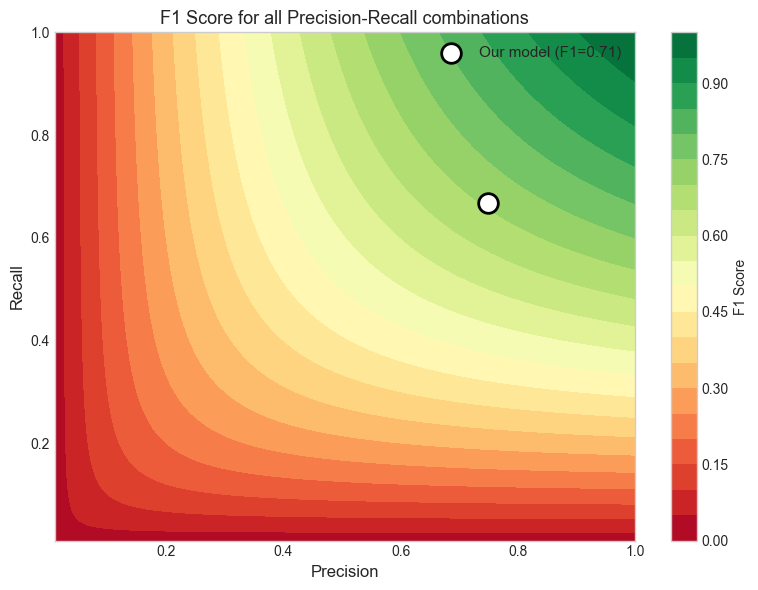

The green diagonal shows that balanced precision and recall gives higher F1.


In [22]:
# Visual: how F1 punishes imbalance
precisions_grid = np.linspace(0.01, 1.0, 100)
recalls_grid = np.linspace(0.01, 1.0, 100)
P, R = np.meshgrid(precisions_grid, recalls_grid)
F1 = 2 * P * R / (P + R)

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(P, R, F1, levels=20, cmap='RdYlGn')
plt.colorbar(cs, ax=ax, label='F1 Score')
ax.set_xlabel('Precision', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title('F1 Score for all Precision-Recall combinations', fontsize=13)

# Mark our model
ax.scatter([precision_manual], [recall_manual], s=200, color='white',
           edgecolors='black', linewidths=2, zorder=5,
           label=f'Our model (F1={f1_manual:.2f})')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("The green diagonal shows that balanced precision and recall gives higher F1.")

---
## Section 9 — ROC Curve & AUC

### Intuition

Precision, recall, and F1 all evaluate performance **at a single threshold**. But what if we want to evaluate how good the model is **across all possible thresholds**?

The **ROC curve** (Receiver Operating Characteristic) does exactly this.

It plots:
- **Y-axis:** True Positive Rate (= Recall = sensitivity) — How many actual positives do we catch?
- **X-axis:** False Positive Rate — How many actual negatives do we accidentally flag?

$$\text{TPR} = \frac{TP}{TP + FN} \quad \text{(same as Recall)}$$

$$\text{FPR} = \frac{FP}{FP + TN}$$

**What makes a good ROC curve?**
- **Top-left corner** = perfect model (high TPR, low FPR)
- **Diagonal line** = random guessing
- The further the curve bulges toward the **top-left**, the better the model

### AUC — Area Under the Curve

AUC summarizes the entire ROC curve into **one number**:
- **AUC = 1.0** → Perfect model
- **AUC = 0.5** → No better than random guessing
- **AUC = 0.0** → Perfectly wrong (flipping predictions would be perfect)

**Intuition:** AUC = probability that the model ranks a random positive higher than a random negative.

In [28]:
# ROC curve for our logistic regression model
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# Also create a "bad" model (random) and a "perfect" model for comparison
np.random.seed(0)
random_proba = np.random.rand(len(y_test))
fpr_rand, tpr_rand, _ = roc_curve(y_test, random_proba)
auc_rand = roc_auc_score(y_test, random_proba)

print(f"Our model AUC:   {auc_score:.3f}")
print(f"Random model AUC: {auc_rand:.3f}")
print()
print(f"Our model is much better than random guessing!")

Our model AUC:   0.915
Random model AUC: 0.537

Our model is much better than random guessing!


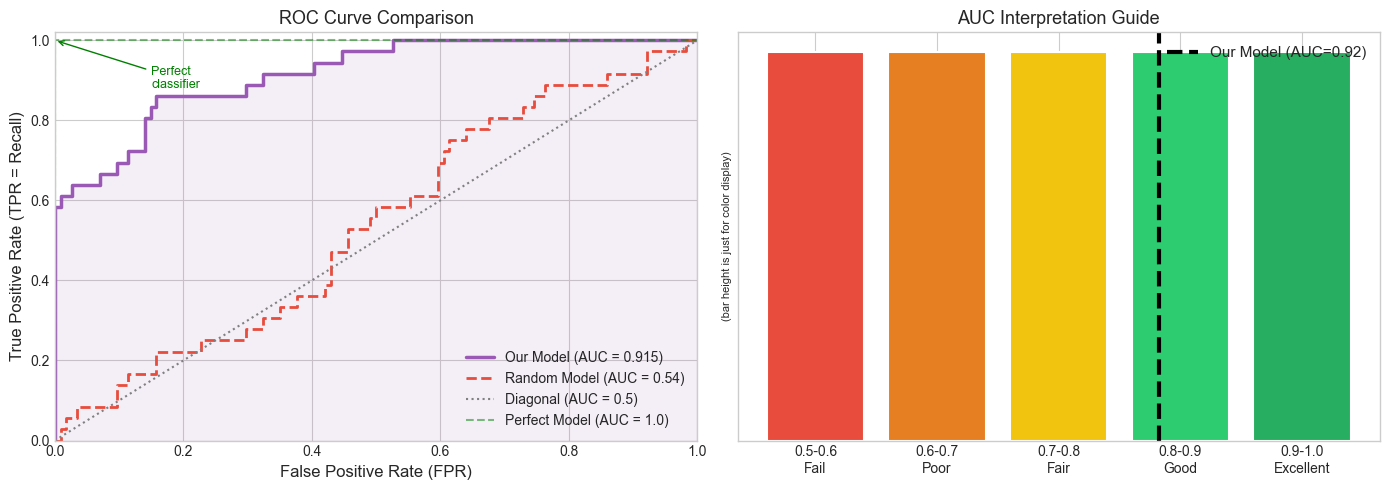

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ROC comparison
ax1 = axes[0]
ax1.plot(fpr, tpr, color='#9b59b6', lw=2.5, label=f'Our Model (AUC = {auc_score:.3f})')
ax1.plot(fpr_rand, tpr_rand, color='#e74c3c', lw=2, linestyle='--',
         label=f'Random Model (AUC = {auc_rand:.2f})')
ax1.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1.5, label='Diagonal (AUC = 0.5)')
ax1.plot([0, 0, 1], [0, 1, 1], 'g--', lw=1.5, alpha=0.5, label='Perfect Model (AUC = 1.0)')

ax1.fill_between(fpr, tpr, alpha=0.1, color='#9b59b6')
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR = Recall)', fontsize=12)
ax1.set_title('ROC Curve Comparison', fontsize=13)
ax1.legend(fontsize=10, loc='lower right')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1.02)

# Annotate corners
ax1.annotate('Perfect\nclassifier', xy=(0, 1), xytext=(0.15, 0.88),
             fontsize=9, color='green',
             arrowprops=dict(arrowstyle='->', color='green'))

# Right: AUC interpretation guide
ax2 = axes[1]
auc_ranges = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels_auc = ['0.5-0.6\nFail', '0.6-0.7\nPoor', '0.7-0.8\nFair', '0.8-0.9\nGood', '0.9-1.0\nExcellent']
colors_auc = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

bars = ax2.bar(labels_auc, [0.1]*5, color=colors_auc, edgecolor='white', linewidth=1.5)
ax2.axvline(x=4*(auc_score-0.5)/0.5 - 0.5, color='black', lw=3, linestyle='--',
            label=f'Our Model (AUC={auc_score:.2f})')
ax2.set_title('AUC Interpretation Guide', fontsize=13)
ax2.set_ylabel('(bar height is just for color display)', fontsize=8)
ax2.legend(fontsize=11)
ax2.set_yticks([])

plt.tight_layout()
plt.show()

### Why use ROC/AUC instead of accuracy?

- AUC works well even on **imbalanced datasets**
- It evaluates the model's **ranking ability** — how well it separates positives from negatives
- It's **threshold-independent** — it tells you the model's overall quality, not just at one cutoff

---
## Section 10 — Putting It All Together

### The Full Picture

Let's train a proper model and compute **all metrics** to see what each one tells us.

We'll compare two models:
1. A **Random Forest** (usually a strong model)
2. The **"Always Predict Negative"** lazy baseline

In [23]:
# Train two classifiers on the same data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Lazy model
y_pred_lazy = np.zeros(len(y_test), dtype=int)

print("Random Forest predictions:", y_pred_rf[:20])
print("Lazy model predictions:   ", y_pred_lazy[:20])
print("Actual labels:            ", y_test[:20])

Random Forest predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
Lazy model predictions:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual labels:             [0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [24]:
# Compare all metrics side by side
def compute_metrics(y_true, y_pred, y_proba=None, name=''):
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_proba) if y_proba is not None else float('nan')
    }
    return metrics

metrics_lr   = compute_metrics(y_test, y_pred_default, y_proba, 'Logistic Regression')
metrics_rf   = compute_metrics(y_test, y_pred_rf, y_proba_rf, 'Random Forest')
metrics_lazy = compute_metrics(y_test, y_pred_lazy, None, 'Lazy (Always Negative)')

results = pd.DataFrame([metrics_lr, metrics_rf, metrics_lazy]).set_index('Model')
print(results.round(3).to_string())

                        Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                                 
Logistic Regression        0.887      0.880   0.611     0.721    0.915
Random Forest              0.907      0.958   0.639     0.767    0.954
Lazy (Always Negative)     0.760      0.000   0.000     0.000      NaN


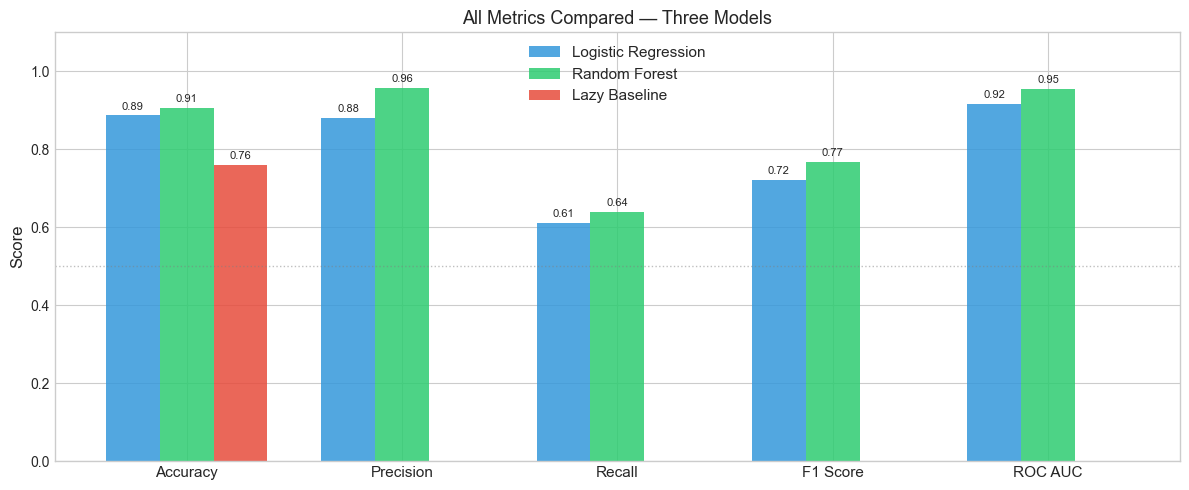

In [25]:
# Visualize all metrics in a radar-style bar chart
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
x = np.arange(len(metrics_list))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width, results.loc['Logistic Regression', metrics_list],
               width, label='Logistic Regression', color='#3498db', alpha=0.85)
bars2 = ax.bar(x, results.loc['Random Forest', metrics_list],
               width, label='Random Forest', color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + width, results.loc['Lazy (Always Negative)', metrics_list].fillna(0),
               width, label='Lazy Baseline', color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Metrics Compared — Three Models', fontsize=13)
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle=':', lw=1, alpha=0.5)

# Add value labels
for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

NameError: name 'fpr' is not defined

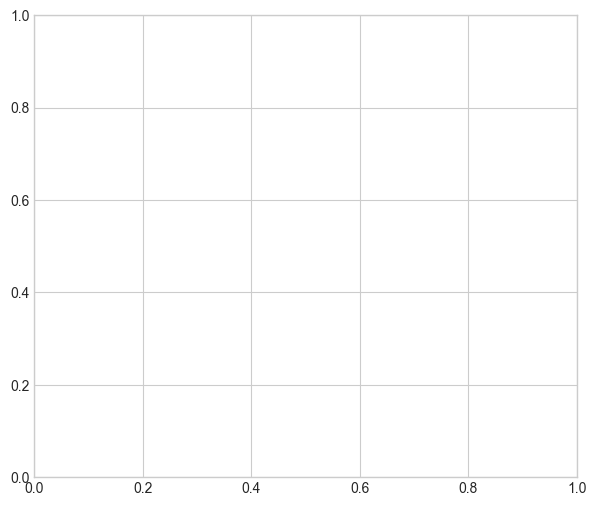

In [26]:
# Final ROC comparison
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#3498db', lw=2.5, label=f'Logistic Regression (AUC={auc_score:.3f})')
ax.plot(fpr_rf, tpr_rf, color='#2ecc71', lw=2.5, label=f'Random Forest (AUC={auc_rf:.3f})')
ax.plot([0, 1], [0, 1], 'gray', linestyle=':', lw=1.5, label='Random (AUC=0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#3498db')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.08, color='#2ecc71')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

In [27]:
# The full sklearn classification report — useful in practice
print("=" * 60)
print("RANDOM FOREST — Full Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Negative', 'Positive']))

RANDOM FOREST — Full Classification Report
              precision    recall  f1-score   support

    Negative       0.90      0.99      0.94       114
    Positive       0.96      0.64      0.77        36

    accuracy                           0.91       150
   macro avg       0.93      0.82      0.85       150
weighted avg       0.91      0.91      0.90       150



---
## Final Summary — Metric Cheat Sheet

| Metric | Formula | Plain English | Use When |
|--------|---------|---------------|----------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | How often are we right overall? | Classes are balanced |
| **Precision** | TP/(TP+FP) | When we say positive, how sure are we? | False alarms are costly |
| **Recall** | TP/(TP+FN) | Of all actual positives, what % did we catch? | Missing positives is costly |
| **F1 Score** | 2·P·R/(P+R) | Balanced score of P and R | Imbalanced data, want one number |
| **ROC AUC** | Area under TPR vs FPR curve | How well does model rank positives over negatives? | Comparing models, imbalanced data |

---

